<img src="https://raw.githubusercontent.com/KristenScotti//Workshops/main/img/UL_CMU_Logo_Horiz_Red.png"
     alt="CMU Libraries Logo" width="30%" height="30%" style="float: left; margin-left: -20px;">

# Introduction to Machine Learning with Python

In this workshop series, we will explore the fundamentals of machine learning using scikit-learn. Participants will learn essential techniques for data preparation, model building, and evaluation through practical, hands-on exercises. This curriculum is designed for beginners, providing a clear and straightforward introduction to machine learning concepts. By the end of the workshop, you will have an understanding of how to apply these skills to real-world problems, regardless of your prior programming experience.

This is a three-part workshop series:

* Part 1: Introduction to Machine Learning and Supervised Methods
* Part 2: Ensemble Methods
* Part 3: Unsupervised Methods and Neural Networks

<div align="center">
  <img src="https://raw.githubusercontent.com/KristenScotti/Workshops/main/img/ML_summary.png"
       width="40%">
</div>

## Instructor

Kristen Scotti\
STEM Librarian\
kscotti@andrew.cmu.edu

License: CC-By Attribution 4.0 International

Adapted from: https://carpentries-incubator.github.io/machine-learning-novice-sklearn/index.html

# Part 1: Introduction to Machine Learning and Supervised Methods

## What is Machine Learning?

Machine Learning (ML) is a way to teach computers to use data to do things like find trends, classify information, make predictions, or interact with an environment to achieve certain goals.

## AI vs ML vs DL
* Artificial Intelligence (AI) is the broadest term and includes any technology that can simulate human-like intelligence.
* Machine Learning (ML) is a subset of AI focused on allowing computers to "learn" patterns from large sets of data to solve specific tasks.
* Deep Learning (DL) is a subset of ML that uses complex structures called neural networks to learn from large amounts of data.

<div align="center">
  <img src="https://raw.githubusercontent.com/KristenScotti/Workshops/main/img/AI_ML_DL.png"
       width="40%">
</div>

## Can you think of some everyday examples of machine learning?

## Limitations of Machine Learning
* Garbage in = garbage out
* Biases due to training data
* Extrapolation
* Over fitting
* Inability to explain answers

## Scikit-Learn

In [1]:
import sklearn
print('scikit-learn:', sklearn.__version__)

scikit-learn: 1.6.1


### Representation of data in Scikit-Learn

* Features Matrix (X): The data used to make predictions
* Target Array (y): The value or category the model is trying to predict.


<div align="center">
  <img src="https://raw.githubusercontent.com/KristenScotti/Workshops/main/img/scikitLearn_DataRepresentation.png"
       width="40%">
</div>

## Supervised Learning

* We are the supervisor, or teacher, providing labeled data that contains example answers of what we want the algorithm to do.

* Supervised learning is split into two further categories:
  * Regression: Labeled data are continuous
  * Classification: Labeled data are discrete

### Regression

#### Linear Regression

Anscombe’s Quartet is a classic dataset that shows how different datasets can have nearly identical summary statistics while looking very different when visualized. This is available in the Python library, Seaborn.

In [2]:
import seaborn as sns

# Get a list of all available datasets
datasets = sns.get_dataset_names()
print(datasets)

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [3]:
# Anscombe's Quartet consists of 4 sets of data
data = sns.load_dataset("anscombe")
print(data.head())

  dataset     x     y
0       I  10.0  8.04
1       I   8.0  6.95
2       I  13.0  7.58
3       I   9.0  8.81
4       I  11.0  8.33


In [4]:
# Split out the 1st dataset from the total

data_1 = data[data["dataset"]=="I"]
data_1 = data_1.sort_values("x")

# Inspect the data
print(data_1.head())

   dataset    x     y
7        I  4.0  4.26
10       I  5.0  5.68
6        I  6.0  7.24
9        I  7.0  4.82
1        I  8.0  6.95


Visually inspect the data

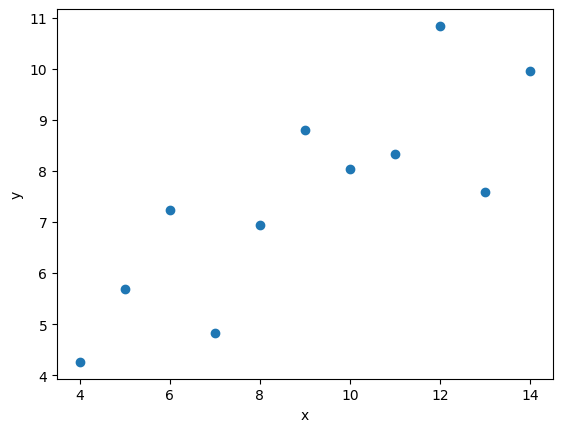

In [5]:
import matplotlib.pyplot as plt

plt.scatter(data_1["x"], data_1["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Create a linear regression model that will try to predict y-values based on x-values

First, let's define a function to pre-process our data into a format the scikit-learn can use

In [6]:
import numpy as np
def pre_process_linear(x, y):
  x_data = np.array(x).reshape(-1, 1)
  y_data = np.array(y).reshape(-1, 1)
  return x_data, y_data

Define a model and train it on the pre-processed data

In [7]:
from sklearn.linear_model import LinearRegression

def fit_a_linear_model(x_data, y_data):
    # Define our estimator/model
    model = LinearRegression(fit_intercept=True)

    # train our estimator/model using our data
    lin_regress = model.fit(x_data,y_data)

    # inspect the trained estimator/model parameters
    m = lin_regress.coef_
    c = lin_regress.intercept_
    print("linear coefs=",m, c)

    return lin_regress

Root Mean Squared Error (RMSE)

In [8]:
# define a function to make predictions using a linear regression model and calculates the
# Root Mean Squared Error (RMSE) as a quality of fit metric

import math
from sklearn.metrics import mean_squared_error

def predict_linear_model(lin_regress, x_data, y_data):
    linear_data = lin_regress.predict(x_data)

    # calculated a RMS error as a quality of fit metric
    error = math.sqrt(mean_squared_error(y_data, linear_data))
    print("linear error=",error)

    # return the predicted y-values
    return linear_data

Plot our data and the fitted model

In [9]:
def plot_linear_model(x_data, y_data, predicted_data):
    plt.scatter(x_data, y_data, label="input")
    plt.plot(x_data, predicted_data, "-", label="fit")
    plt.plot(x_data, predicted_data, "rx", label="predictions")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()

Putting the whole workflow together:

In [10]:
def fit_predict_plot_linear(x, y):
  x_data, y_data = pre_process_linear(x, y)
  lin_regress = fit_a_linear_model(x_data, y_data)
  linear_data = predict_linear_model(lin_regress, x_data, y_data)
  plot_linear_model(x_data, y_data, linear_data)
  return lin_regress

Now that we've defined a function that handles the full regression workflow, we can simply give it the x and y columns from Dataset I:

linear coefs= [[0.50009091]] [3.00009091]
linear error= 1.1185497916336296


LinearRegression()

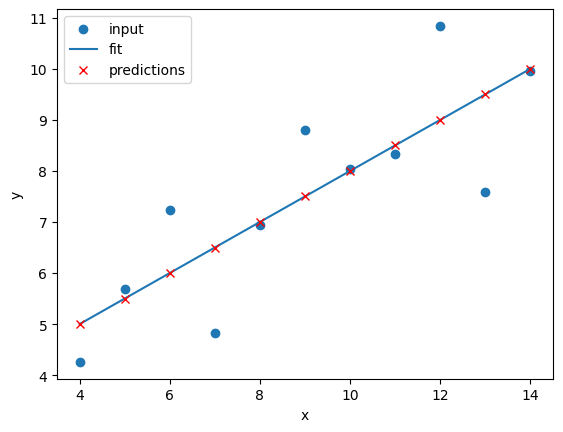

In [46]:
fit_predict_plot_linear(data_1["x"], data_1["y"])

Fit Dataset II:

linear coefs= [[0.5]] [3.00090909]
linear error= 1.1191023557497446


LinearRegression()

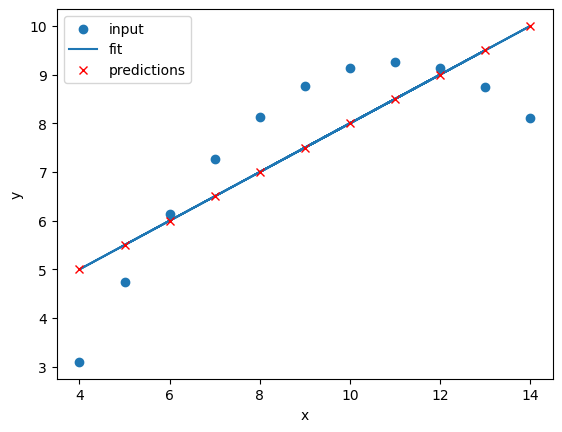

In [45]:
data_2 = data[data["dataset"]=="II"]
fit_predict_plot_linear(data_2["x"],data_2["y"])

**Exercise**: Repeat the linear regression exercise for Datasets III and IV.

Adjust your code to repeat the linear regression for the other datasets. What can you say about the similarities and/or differences between the linear regressions on the 4 datasets?

In [48]:
# Dataset III

In [ ]:
# Dataset IV

#### Polynomial Regression

A polynomial can include powers of x, such as:

$y = a + bx + cx^2+ dx^3 +  ...$

* Degree 1: $y = a + bx$ (a straight line)
* Degree 2: $y = a + bx + cx^2$ (curved, quadratic relationship)

In [51]:
from sklearn.preprocessing import PolynomialFeatures

# define function that prepares inputs for polynomial regression
def pre_process_poly(x, y):
    x_data = np.array(x).reshape(-1, 1)
    y_data = np.array(y).reshape(-1, 1)

    poly_features = PolynomialFeatures(degree=2, include_bias=False)
    x_poly = poly_features.fit_transform(x_data)

    return x_poly, x_data, y_data

# Function that trains a linear model on the polynomial design matrix
def fit_poly_model(x_poly, y_data):
    # Define our estimator/model(s)
    poly_regress = LinearRegression()

    # define and train our model
    poly_regress.fit(x_poly,y_data)

    # inspect trained model parameters
    poly_m = poly_regress.coef_
    poly_c = poly_regress.intercept_
    print("poly_coefs",poly_m, poly_c)
    return poly_regress

def predict_poly_model(poly_regress, x_poly, y_data):
    poly_data = poly_regress.predict(x_poly)
    poly_error = math.sqrt(mean_squared_error(y_data, poly_data))
    print("poly error=", poly_error)
    return poly_data

def plot_poly_model(x_data, poly_data):
    plt.plot(x_data, poly_data, label="poly fit")
    plt.legend()

def fit_predict_plot_poly(x, y):
    x_poly, x_data, y_data = pre_process_poly(x, y)
    poly_regress = fit_poly_model(x_poly, y_data)
    poly_data = predict_poly_model(poly_regress, x_poly, y_data)
    plot_poly_model(x_data, poly_data)
    return poly_regress

Compare linear and polynomial regression

linear coefs= [[0.5]] [3.00090909]
linear error= 1.1191023557497446
poly_coefs [[ 2.78083916 -0.12671329]] [-5.99573427]
poly error= 0.0014262991646409617


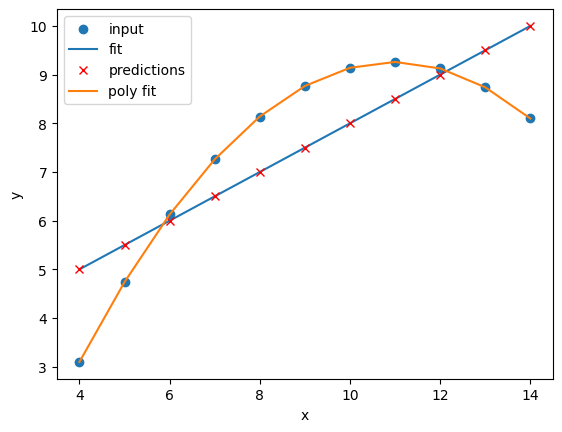

In [52]:
# Sort our data in order of our x (feature) values
data_2 = data[data["dataset"]=="II"]
data_2 = data_2.sort_values("x")

fit_predict_plot_linear(data_2["x"],data_2["y"])
fit_predict_plot_poly(data_2["x"],data_2["y"])

plt.show()

Let’s explore a more realistic scenario

In [15]:
dataset = sns.load_dataset("penguins")
dataset.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


We have seven columns in total:

* Four continuous (numerical) columns named bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g;
* Three discrete (categorical) columns named species, island, and sex.

From a quick inspection of the first five samples, we have some missing data in the form of NaN values. Let’s go ahead and remove any rows that contain NaN values:

In [16]:
dataset.dropna(inplace=True)
dataset.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Predict bill depth from body mass

linear coefs= [[0.00154247]] [12.63062456]
linear error= 0.989750418206048


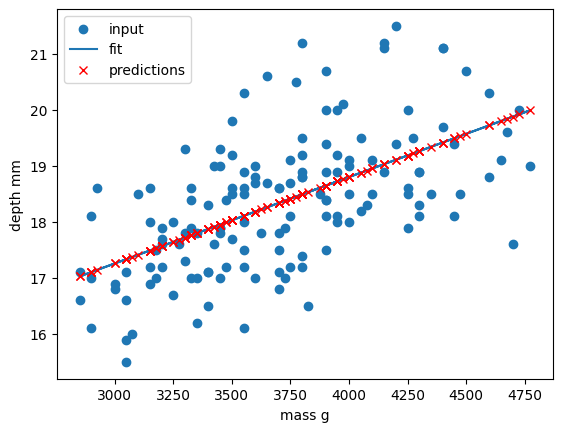

In [17]:
dataset_1 = dataset[:146]
x_data = dataset_1["body_mass_g"]
y_data = dataset_1["bill_depth_mm"]
trained_model = fit_predict_plot_linear(x_data, y_data)
plt.xlabel("mass g")
plt.ylabel("depth mm")
plt.show()

How does the model perform on the rest of the data?

linear error= 3.399494458297147


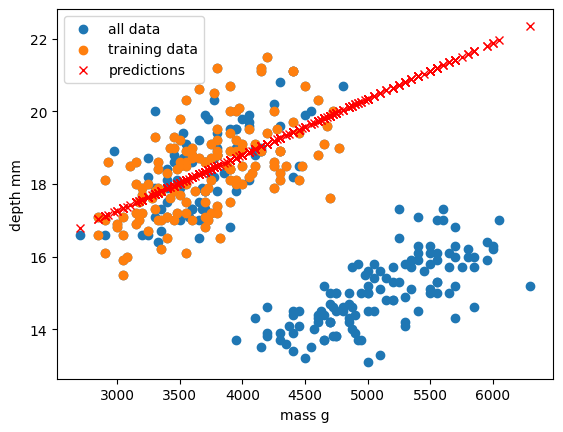

In [50]:
x_data_all, y_data_all = pre_process_linear(
    dataset["body_mass_g"],
    dataset["bill_depth_mm"]
    )

y_predictions = predict_linear_model(
    trained_model,
    x_data_all,
    y_data_all
    )

plt.scatter(x_data_all, y_data_all, label="all data")
plt.scatter(x_data, y_data, label="training data")
plt.plot(x_data_all, y_predictions, "rx", label="predictions")
plt.xlabel("mass g")
plt.ylabel("depth mm")
plt.legend()
plt.show()

What happened?

### Classification
A supervised method to recognize and group data objects into pre-determined categories

<div align="center">
  <img src="https://raw.githubusercontent.com/KristenScotti/Workshops/main/img/ML_summary.png"
       width="40%">
</div>

In [19]:
import sklearn
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
dataset = sns.load_dataset('penguins')
dataset.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Preprocessing our data

In [21]:
feature_names = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
dataset.dropna(subset=feature_names, inplace=True)
class_names = dataset['species'].unique()
X = dataset[feature_names]
y = dataset['species']

Training-testing split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Visualize data

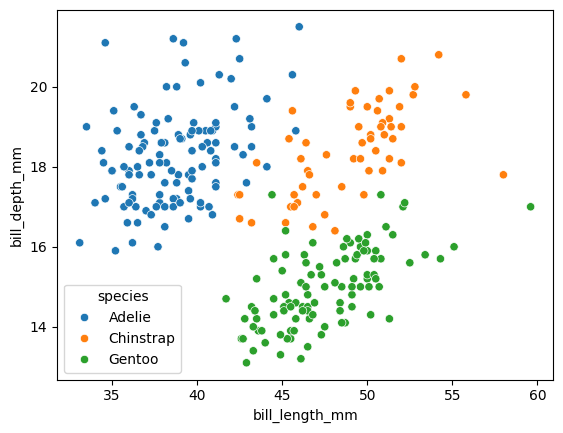

In [23]:
fig01 = sns.scatterplot(X_train, x=feature_names[0], y=feature_names[1], hue=dataset['species'])
plt.show()


As there are four measurements for each penguin, we need quite a few plots to visualise all four dimensions against each other.

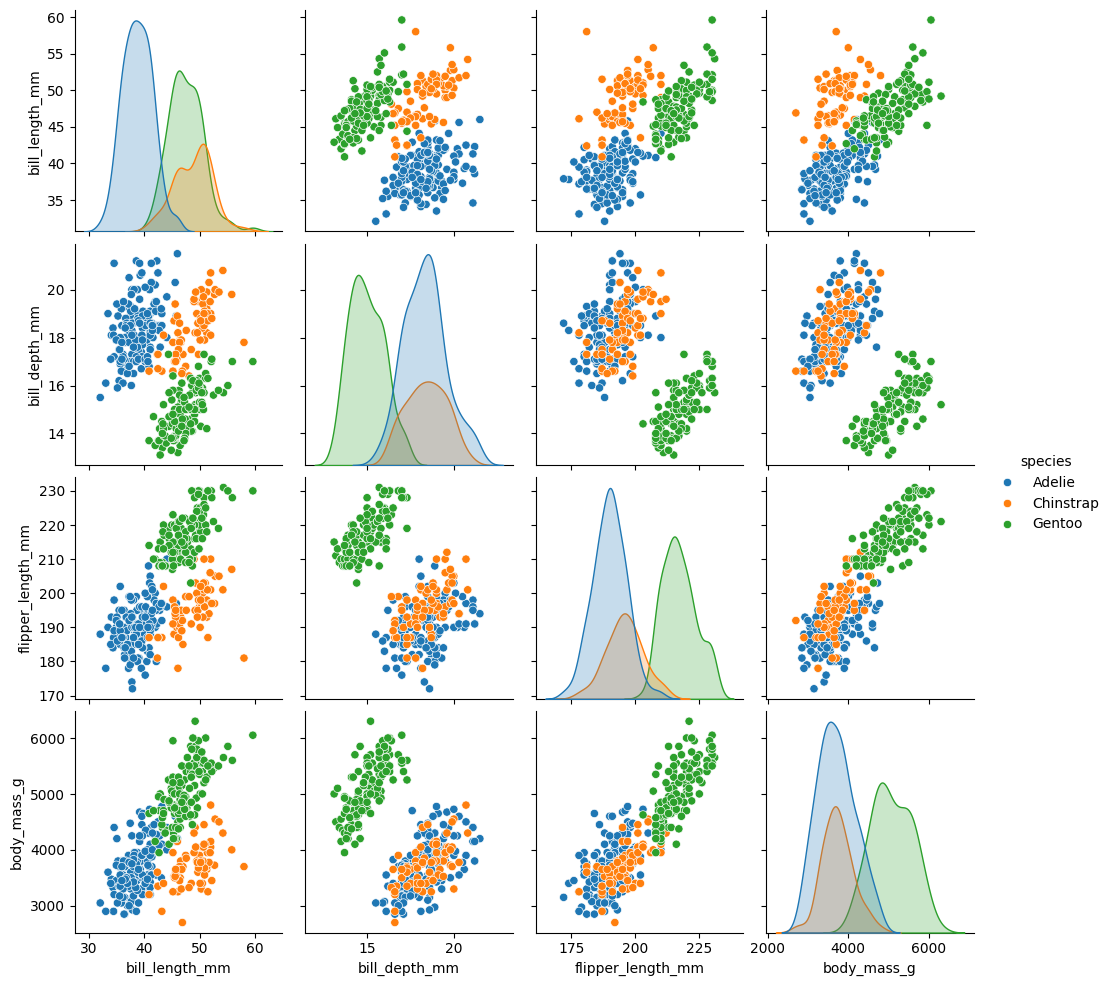

In [24]:
sns.pairplot(dataset, hue="species")
plt.show()

#### Classification using a decision tree

<div align="center">
  <img src="https://raw.githubusercontent.com/KristenScotti/Workshops/main/img/decision_tree_example.png"
       width="40%">
</div>

In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train, y_train)
clf.predict(X_test)

array(['Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo',
       'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Adelie', 'Adelie', 'Chinstrap', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo',
       'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Chinstrap', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Chinstrap', 'Adelie'], dtype=object)

Evaluation

In [26]:
clf_score = clf.score(X_test, y_test)
print(clf_score)

0.9855072463768116


Decision tree

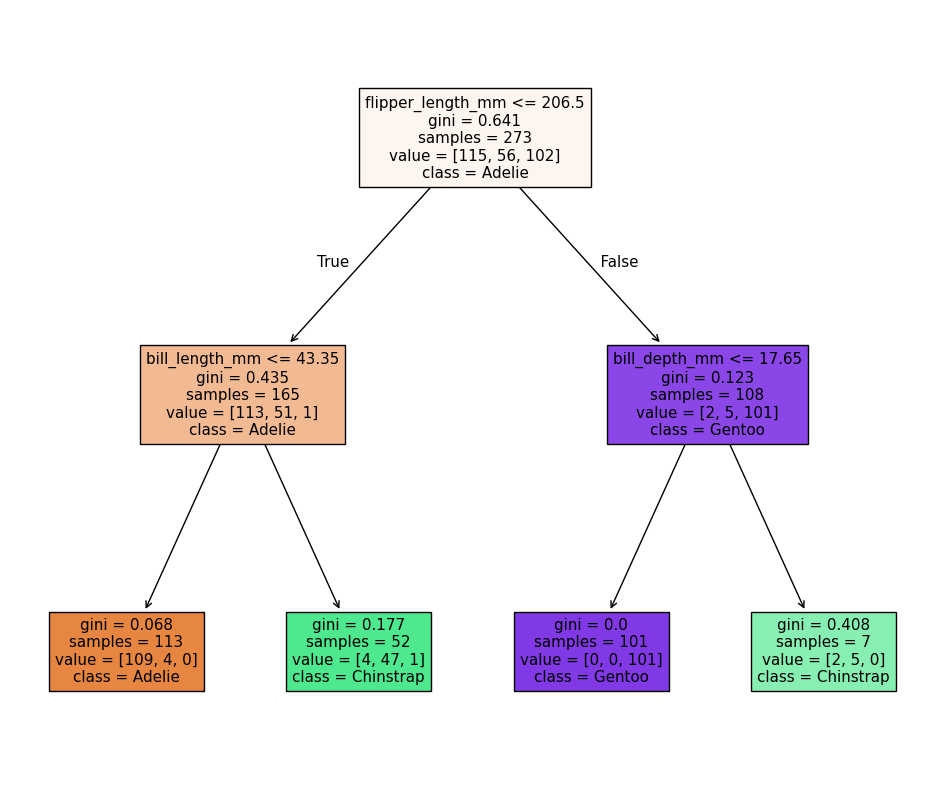

In [27]:
fig = plt.figure(figsize=(12, 10))
plot_tree(clf, class_names=class_names, feature_names=feature_names, filled=True, ax=fig.gca())
plt.show()

Visualising the classification space

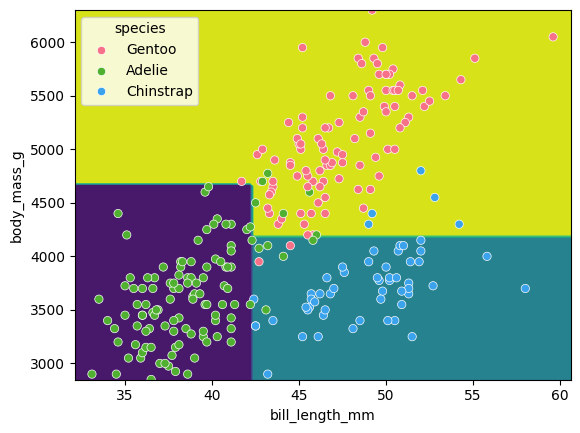

In [29]:
from sklearn.inspection import DecisionBoundaryDisplay
f1 = feature_names[0]
f2 = feature_names[3]
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train[[f1, f2]], y_train)
d = DecisionBoundaryDisplay.from_estimator(clf, X_train[[f1, f2]])
sns.scatterplot(X_train, x=f1, y=f2, hue=y_train, palette="husl")
plt.show()

Tuning the max_depth hyperparameter

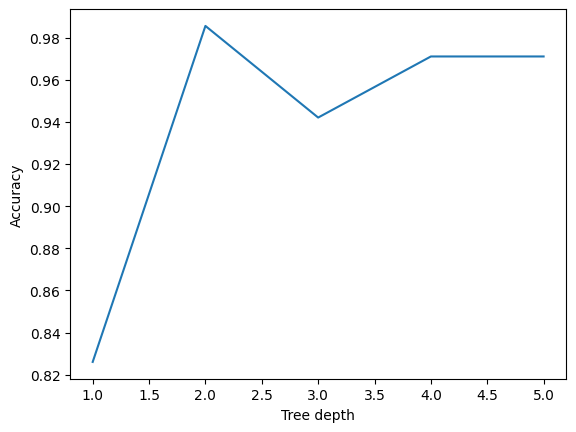

In [30]:
import pandas as pd

max_depths = [1, 2, 3, 4, 5]

accuracy = []

for i, d in enumerate(max_depths):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)

    accuracy.append((d, acc))

acc_df = pd.DataFrame(accuracy, columns=['depth', 'accuracy'])

sns.lineplot(acc_df, x='depth', y='accuracy')

plt.xlabel('Tree depth')
plt.ylabel('Accuracy')
plt.show()

Reuse our fitting and plotting codes from above to inspect a decision tree that has max_depth=5

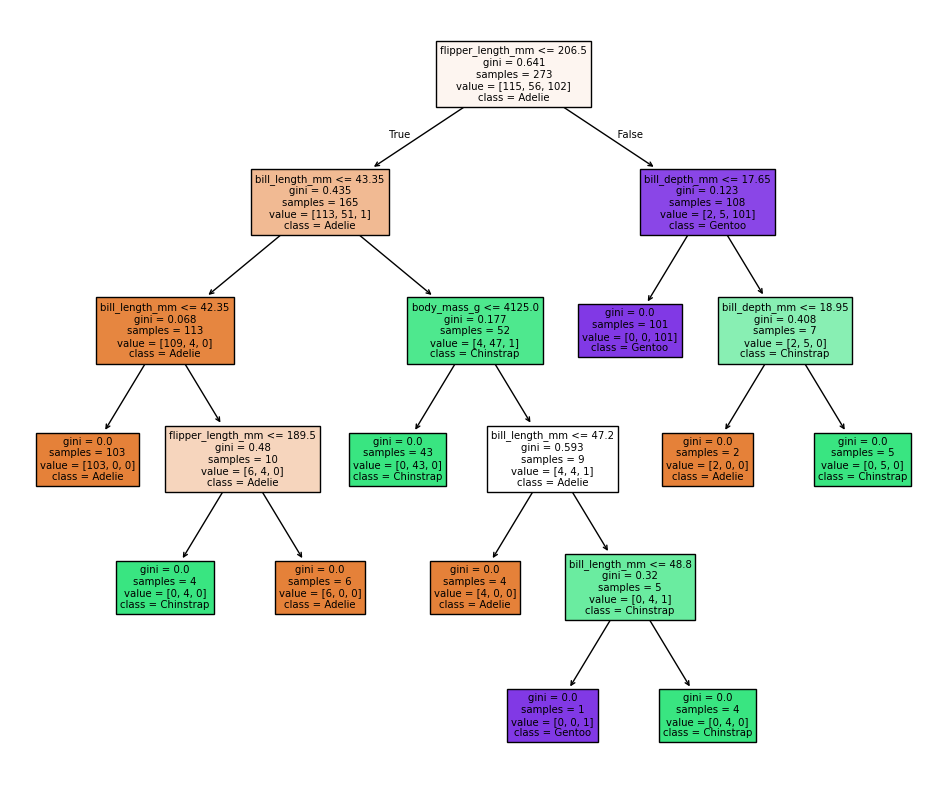

In [31]:
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train, y_train)

fig = plt.figure(figsize=(12, 10))
plot_tree(clf, class_names=class_names, feature_names=feature_names, filled=True, ax=fig.gca())
plt.show()

Visualize the classification space

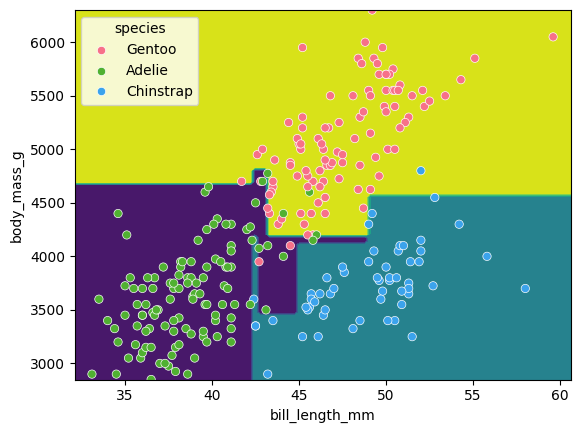

In [32]:
f1 = feature_names[0]
f2 = feature_names[3]

clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train[[f1, f2]], y_train)

d = DecisionBoundaryDisplay.from_estimator(clf, X_train[[f1, f2]])

sns.scatterplot(X_train, x=f1, y=f2, hue=y_train, palette='husl')
plt.show()

#### Support Vector Machines (SVM)

* A type of classification algorithm used to find the best way to separate different classes of data points
* SVMs look for a hyperplane (a line in 2D, a plane in 3D, or a higher-dimensional equivalent) that separates different classes of data points

In [33]:
from sklearn import preprocessing
scalar = preprocessing.StandardScaler()
scalar.fit(X_train)
X_train_scaled = pd.DataFrame(scalar.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scalar.transform(X_test), columns=X_test.columns, index=X_test.index)

In [34]:
from sklearn import svm
SVM = svm.SVC(kernel='poly', degree=3, C=1.5)
SVM.fit(X_train_scaled, y_train)
svm_score = SVM.score(X_test_scaled, y_test)
print("Decision tree score is ", clf_score)
print("SVM score is ", svm_score)

Decision tree score is  0.9855072463768116
SVM score is  0.9565217391304348


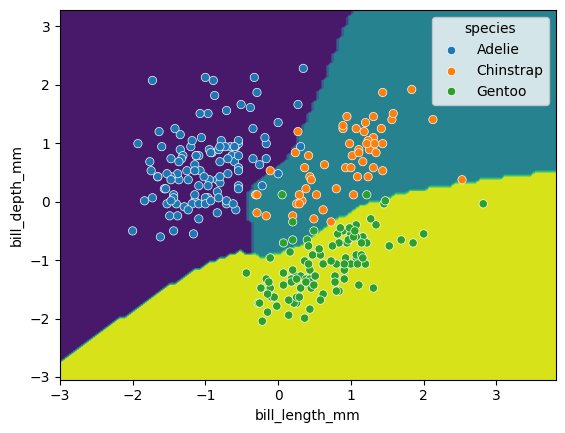

In [35]:
x2 = X_train_scaled[[feature_names[0], feature_names[1]]]
SVM = svm.SVC(kernel='poly', degree=3, C=1.5)
SVM.fit(x2, y_train)
DecisionBoundaryDisplay.from_estimator(SVM, x2)
sns.scatterplot(x=x2[feature_names[0]], y=x2[feature_names[1]], hue=dataset['species'])
plt.show()